In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv("data/participant_data.csv")

In [3]:
dataset.head(5)

,timestamp,ai_use,baseline_trust,comfort,selected_task,decision_confidence,ai_influence,trust_1,trust_2,trust_3,transparency_1,transparency_2,ux_1,ux_2,open_trust,open_explanation,open_improvement,condition_key
0,2026-05-31T18:27:26.562435-07:00,5,2,1,Organize Notes,2,2,2,1,3,6,1,2,3,NaN,NaN,NaN,minimal_explanation
1,2026-05-31T21:41:43.277062-07:00,6,6,6,Draft Project Report,7,6,6,6,6,7,7,7,7,The advice AI gave just made sense and there w...,"Helpful,",If you really want to know how much AI has an ...,transparent_explanation
2,2026-05-31T21:50:50.663039-07:00,4,4,4,Draft Project Report,7,2,6,4,4,7,7,7,4,The AI had sound reasoning to support its reco...,It felt helpful,It would help to go through a few examples to ...,uncertainty_calibrated
3,2026-05-31T22:22:57.495345-07:00,5,4,5,Draft Project Report,5,4,1,1,1,4,5,6,5,NaN,NaN,NaN,high_confidence
4,2026-06-02T10:44:18.296014-07:00,6,5,7,Review Course Module,7,1,7,7,7,7,6,7,7,The ai singled out the most urgent task accura...,"The explanation was clear, coherent and accura...",adding condiitons to recommendations would mak...,high_confidence


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   timestamp            21 non-null     str  
 1   ai_use               21 non-null     int64
 2   baseline_trust       21 non-null     int64
 3   comfort              21 non-null     int64
 4   selected_task        20 non-null     str  
 5   decision_confidence  21 non-null     int64
 6   ai_influence         21 non-null     int64
 7   trust_1              21 non-null     int64
 8   trust_2              21 non-null     int64
 9   trust_3              21 non-null     int64
 10  transparency_1       21 non-null     int64
 11  transparency_2       21 non-null     int64
 12  ux_1                 21 non-null     int64
 13  ux_2                 21 non-null     int64
 14  open_trust           15 non-null     str  
 15  open_explanation     15 non-null     str  
 16  open_improvement     12 non-null     st

In [5]:
dataset.isnull().sum()

timestamp              0
ai_use                 0
baseline_trust         0
comfort                0
selected_task          1
decision_confidence    0
ai_influence           0
trust_1                0
trust_2                0
trust_3                0
transparency_1         0
transparency_2         0
ux_1                   0
ux_2                   0
open_trust             6
open_explanation       6
open_improvement       9
condition_key          0
dtype: int64

In [6]:
dataset["trust_score"] = ((dataset["trust_1"] + 
                          dataset["trust_2"] + 
                          dataset["trust_3"]) / 3).round(2)

In [7]:
dataset['transparency_score'] = ((dataset ["transparency_1"] + 
                                   dataset ["transparency_2"]) / 2).round(2)

In [8]:
dataset['ux_score'] = ((dataset ['ux_1'] + dataset ['ux_2'])/2).round (2)

In [9]:
dataset

,timestamp,ai_use,baseline_trust,comfort,selected_task,decision_confidence,ai_influence,trust_1,trust_2,trust_3,...,transparency_2,ux_1,ux_2,open_trust,open_explanation,open_improvement,condition_key,trust_score,transparency_score,ux_score
0,2026-05-31T18:27:26.562435-07:00,5,2,1,Organize Notes,2,2,2,1,3,...,1,2,3,NaN,NaN,NaN,minimal_explanation,2.00,3.5,2.5
1,2026-05-31T21:41:43.277062-07:00,6,6,6,Draft Project Report,7,6,6,6,6,...,7,7,7,The advice AI gave just made sense and there w...,"Helpful,",If you really want to know how much AI has an ...,transparent_explanation,6.00,7.0,7.0
2,2026-05-31T21:50:50.663039-07:00,4,4,4,Draft Project Report,7,2,6,4,4,...,7,7,4,The AI had sound reasoning to support its reco...,It felt helpful,It would help to go through a few examples to ...,uncertainty_calibrated,4.67,7.0,5.5
3,2026-05-31T22:22:57.495345-07:00,5,4,5,Draft Project Report,5,4,1,1,1,...,5,6,5,NaN,NaN,NaN,high_confidence,1.00,4.5,5.5
4,2026-06-02T10:44:18.296014-07:00,6,5,7,Review Course Module,7,1,7,7,7,...,6,7,7,The ai singled out the most urgent task accura...,"The explanation was clear, coherent and accura...",adding condiitons to recommendations would mak...,high_confidence,7.00,6.5,7.0
5,2026-06-04T09:00:47.387333-07:00,4,3,1,Draft Project Report,6,6,3,4,4,...,5,5,4,NaN,NaN,NaN,uncertainty_calibrated,3.67,5.0,4.5
6,2026-06-05T19:58:39.230101-07:00,7,2,5,Draft Project Report,7,1,6,2,2,...,3,2,1,"My baseline trust in the AI is very low, and I...","The explanation felt excessive, going beyond t...",More data points.,transparent_explanation,3.33,3.0,1.5
7,2026-06-05T20:10:57.753203-07:00,3,2,1,Draft Project Report,7,1,7,7,7,...,7,7,1,NaN,NaN,NaN,high_confidence,7.00,7.0,4.0
8,2026-06-05T20:10:03.856211-07:00,7,5,6,Draft Project Report,7,1,4,6,2,...,2,5,1,NaN,NaN,NaN,uncertainty_calibrated,4.00,2.0,3.0
9,2026-06-05T20:14:12.531706-07:00,7,7,5,Draft Project Report,7,1,1,1,1,...,1,1,1,I’d never use AI in that situation,Irrelevant,Nothing,transparent_explanation,1.00,1.0,1.0


In [10]:
dataset['timestamp'] = pd.to_datetime(dataset['timestamp'], utc=True)
dataset['timestamp'].info()

<class 'pandas.Series'>
RangeIndex: 21 entries, 0 to 20
Series name: timestamp
Non-Null Count  Dtype              
--------------  -----              
21 non-null     datetime64[us, UTC]
dtypes: datetime64[us, UTC](1)
memory usage: 300.0 bytes


In [11]:
dataset.columns

Index(['timestamp', 'ai_use', 'baseline_trust', 'comfort', 'selected_task',
       'decision_confidence', 'ai_influence', 'trust_1', 'trust_2', 'trust_3',
       'transparency_1', 'transparency_2', 'ux_1', 'ux_2', 'open_trust',
       'open_explanation', 'open_improvement', 'condition_key', 'trust_score',
       'transparency_score', 'ux_score'],
      dtype='str')

In [12]:
dataset['selected_task'] = dataset['selected_task'].fillna('missing')
dataset['selected_task']

0           Organize Notes
1     Draft Project Report
2     Draft Project Report
3     Draft Project Report
4     Review Course Module
5     Draft Project Report
6     Draft Project Report
7     Draft Project Report
8     Draft Project Report
9     Draft Project Report
10    Draft Project Report
11                 missing
12    Draft Project Report
13    Draft Project Report
14         Reply to Emails
15         Reply to Emails
16    Review Course Module
17    Draft Project Report
18    Draft Project Report
19    Draft Project Report
20    Review Course Module
Name: selected_task, dtype: str

In [13]:
cols = ['open_trust', 'open_explanation', 'open_improvement']
dataset[cols] = dataset[cols].apply(lambda col: col.str.strip()).fillna('no_response')
dataset[cols]

,open_trust,open_explanation,open_improvement
0,no_response,no_response,no_response
1,The advice AI gave just made sense and there w...,"Helpful,",If you really want to know how much AI has an ...
2,The AI had sound reasoning to support its reco...,It felt helpful,It would help to go through a few examples to ...
3,no_response,no_response,no_response
4,The ai singled out the most urgent task accura...,"The explanation was clear, coherent and accurate.",adding condiitons to recommendations would mak...
5,no_response,no_response,no_response
6,"My baseline trust in the AI is very low, and I...","The explanation felt excessive, going beyond t...",More data points.
7,no_response,no_response,no_response
8,no_response,no_response,no_response
9,I’d never use AI in that situation,Irrelevant,Nothing


In [14]:
dataset['followed_ai'] = dataset['selected_task'] == "Draft Project Report"

In [15]:
dataset

,timestamp,ai_use,baseline_trust,comfort,selected_task,decision_confidence,ai_influence,trust_1,trust_2,trust_3,...,ux_1,ux_2,open_trust,open_explanation,open_improvement,condition_key,trust_score,transparency_score,ux_score,followed_ai
0,2026-06-01 01:27:26.562435+00:00,5,2,1,Organize Notes,2,2,2,1,3,...,2,3,no_response,no_response,no_response,minimal_explanation,2.00,3.5,2.5,False
1,2026-06-01 04:41:43.277062+00:00,6,6,6,Draft Project Report,7,6,6,6,6,...,7,7,The advice AI gave just made sense and there w...,"Helpful,",If you really want to know how much AI has an ...,transparent_explanation,6.00,7.0,7.0,True
2,2026-06-01 04:50:50.663039+00:00,4,4,4,Draft Project Report,7,2,6,4,4,...,7,4,The AI had sound reasoning to support its reco...,It felt helpful,It would help to go through a few examples to ...,uncertainty_calibrated,4.67,7.0,5.5,True
3,2026-06-01 05:22:57.495345+00:00,5,4,5,Draft Project Report,5,4,1,1,1,...,6,5,no_response,no_response,no_response,high_confidence,1.00,4.5,5.5,True
4,2026-06-02 17:44:18.296014+00:00,6,5,7,Review Course Module,7,1,7,7,7,...,7,7,The ai singled out the most urgent task accura...,"The explanation was clear, coherent and accurate.",adding condiitons to recommendations would mak...,high_confidence,7.00,6.5,7.0,False
5,2026-06-04 16:00:47.387333+00:00,4,3,1,Draft Project Report,6,6,3,4,4,...,5,4,no_response,no_response,no_response,uncertainty_calibrated,3.67,5.0,4.5,True
6,2026-06-06 02:58:39.230101+00:00,7,2,5,Draft Project Report,7,1,6,2,2,...,2,1,"My baseline trust in the AI is very low, and I...","The explanation felt excessive, going beyond t...",More data points.,transparent_explanation,3.33,3.0,1.5,True
7,2026-06-06 03:10:57.753203+00:00,3,2,1,Draft Project Report,7,1,7,7,7,...,7,1,no_response,no_response,no_response,high_confidence,7.00,7.0,4.0,True
8,2026-06-06 03:10:03.856211+00:00,7,5,6,Draft Project Report,7,1,4,6,2,...,5,1,no_response,no_response,no_response,uncertainty_calibrated,4.00,2.0,3.0,True
9,2026-06-06 03:14:12.531706+00:00,7,7,5,Draft Project Report,7,1,1,1,1,...,1,1,I’d never use AI in that situation,Irrelevant,Nothing,transparent_explanation,1.00,1.0,1.0,True


In [16]:
dataset.to_csv("data/participant_data_cleaned.csv", index=False)

In [17]:
dataset.describe()

,ai_use,baseline_trust,comfort,decision_confidence,ai_influence,trust_1,trust_2,trust_3,transparency_1,transparency_2,ux_1,ux_2,trust_score,transparency_score,ux_score
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.00000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,5.476190,4.428571,4.714286,6.000000,2.857143,4.000000,3.761905,4.00000,4.523810,4.523810,5.142857,3.666667,3.920952,4.523810,4.404762
std,1.435933,1.502379,1.978455,1.414214,1.930951,2.345208,2.364419,2.32379,2.421137,2.358369,2.151411,2.287648,2.139418,2.100453,1.868282
min,3.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,4.000000,3.000000,6.000000,1.000000,1.000000,1.000000,2.00000,2.000000,2.000000,4.000000,1.000000,2.000000,3.000000,3.500000
50%,5.000000,4.000000,5.000000,7.000000,2.000000,4.000000,4.000000,4.00000,5.000000,5.000000,6.000000,4.000000,4.000000,4.500000,4.500000
75%,7.000000,5.000000,6.000000,7.000000,4.000000,6.000000,6.000000,6.00000,7.000000,7.000000,7.000000,5.000000,5.670000,6.500000,5.500000
max,7.000000,7.000000,7.000000,7.000000,6.000000,7.000000,7.000000,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


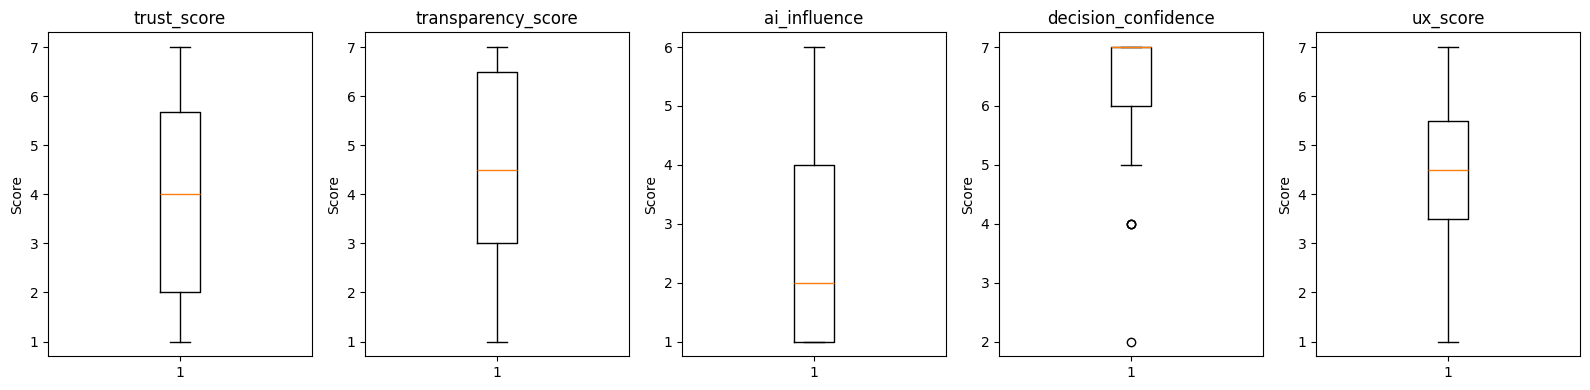

In [18]:
import matplotlib.pyplot as plt

# Create a figure with subplots for each metric
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

# Define the columns to plot
metrics = ['trust_score', 'transparency_score', 'ai_influence', 'decision_confidence', 'ux_score']

# Create a box plot for each metric
for i, metric in enumerate(metrics):
    axes[i].boxplot(dataset[metric])
    axes[i].set_title(metric)
    axes[i].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [19]:
dataset["trust_score"].mean()

np.float64(3.920952380952381)

In [20]:
dataset["transparency_score"].mean()

np.float64(4.523809523809524)

In [21]:
dataset["ai_influence"].mean()

np.float64(2.857142857142857)

In [22]:
corr = dataset[['trust_score', 'transparency_score', 'ai_influence', 'decision_confidence', 'baseline_trust']].corr()
corr

,trust_score,transparency_score,ai_influence,decision_confidence,baseline_trust
trust_score,1.000000,0.695850,-0.256918,0.374472,-0.118514
transparency_score,0.695850,1.000000,0.130322,0.185155,-0.003395
ai_influence,-0.256918,0.130322,1.000000,-0.054929,0.263454
decision_confidence,0.374472,0.185155,-0.054929,1.000000,0.282395
baseline_trust,-0.118514,-0.003395,0.263454,0.282395,1.000000


In [23]:
import scipy.stats as stats

# Calculate correlation and p-values
corr_with_pvalues = pd.DataFrame(index=corr.index, columns=corr.columns)

for col1 in corr.index:
    for col2 in corr.columns:
        r, p_value = stats.pearsonr(dataset[col1], dataset[col2])
        corr_with_pvalues.loc[col1, col2] = f"{r:.3f} (p={p_value:.4f})"

corr_with_pvalues

,trust_score,transparency_score,ai_influence,decision_confidence,baseline_trust
trust_score,1.000 (p=0.0000),0.696 (p=0.0005),-0.257 (p=0.2609),0.374 (p=0.0944),-0.119 (p=0.6089)
transparency_score,0.696 (p=0.0005),1.000 (p=0.0000),0.130 (p=0.5734),0.185 (p=0.4217),-0.003 (p=0.9883)
ai_influence,-0.257 (p=0.2609),0.130 (p=0.5734),1.000 (p=0.0000),-0.055 (p=0.8131),0.263 (p=0.2485)
decision_confidence,0.374 (p=0.0944),0.185 (p=0.4217),-0.055 (p=0.8131),1.000 (p=0.0000),0.282 (p=0.2149)
baseline_trust,-0.119 (p=0.6089),-0.003 (p=0.9883),0.263 (p=0.2485),0.282 (p=0.2149),1.000 (p=0.0000)


To better understand the relationships in the data, I examined the correlation coefficient (r), which measures the strength and direction of a relationship between two variables on a scale from -1 to 1. Values closer to 1 or -1 indicate a stronger relationship, while values closer to 0 indicate little or no relationship. I also examined the p-value to determine whether each relationship was statistically significant. In behavioral research, a threshold of $p < .05$ is commonly used for statistical significance, suggesting that the relationship is unlikely to have occurred by chance. With these benchmarks in mind, the results reveal the following relationships:

### Does trust relate to AI influence?

* **No, there is no statistically significant relationship between trust and AI influence in this dataset.**

* **The Data:** $r = -0.257, p = 0.2609$

* **Interpretation:** The correlation suggests a weak negative trend, meaning that higher trust scores were associated with slightly lower AI influence. However, because $p > .05$, this relationship is not statistically significant. Based on this sample, we cannot conclude that users' trust levels are associated with how much the AI influences their decisions.

### Does transparency relate to trust?

* **Yes, there is a strong, statistically significant positive relationship between transparency and trust.**

* **The Data:** $r = 0.696, p = 0.0005$

* **Interpretation:** This is the strongest relationship observed in the dataset. Participants who rated the AI as more transparent also tended to report higher levels of trust. Because $p < .05$, this relationship is unlikely to have occurred by chance. While correlation does not establish causation, the findings suggest that transparency is strongly associated with higher trust in AI systems.

* **UX implication:** Designing AI systems that clearly communicate their reasoning, limitations, and decision process may help foster greater user trust.

### Does baseline trust relate to AI influence?

* **No, there is no statistically significant relationship between baseline trust and AI influence.**

* **The Data:** $r = 0.263, p = 0.2485$

* **Interpretation:** Although there is a weak positive correlation, the relationship is not statistically significant because $p > .05$. Based on this sample, users' initial level of trust does not appear to predict how much influence the AI has on their decisions.

* *Because this study included 21 participants, non-significant findings should be interpreted cautiously. Larger studies would be needed to determine whether these weak relationships reflect true effects or simply sampling variability.

In [24]:
dataset['condition_key'].value_counts()

condition_key
high_confidence            7
uncertainty_calibrated     6
minimal_explanation        4
transparent_explanation    4
Name: count, dtype: int64

Twenty-one participants were randomly assigned to one of four AI communication conditions: High Confidence ($n = 7$), Uncertainty-Calibrated ($n = 6$), Minimal Explanation ($n = 4$), and Transparent Explanation ($n = 4$). Due to the modest sample size within each condition, between-group analyses were treated as exploratory.

## Experimental Condition Summary

In [25]:
condition_summary = dataset.groupby("condition_key")[[
    "trust_score",
    "transparency_score",
    "ai_influence",
    "decision_confidence",
    "ux_score"
]].agg(["mean", "std", "count"]).round(2)

condition_summary

trust_score             transparency_score        \
                               mean   std count               mean   std   
condition_key                                                              
high_confidence                3.95  3.00     7               4.36  2.17   
minimal_explanation            3.92  1.71     4               5.12  1.65   
transparent_explanation        3.92  2.25     4               4.38  2.87   
uncertainty_calibrated         3.89  1.64     6               4.42  2.25   

                              ai_influence             decision_confidence  \
                        count         mean   std count                mean   
condition_key                                                                
high_confidence             7         2.14  1.35     7                5.57   
minimal_explanation         4         3.50  1.73     4                4.75   
transparent_explanation     4         2.50  2.38     4                7.00   
uncertainty_calibrated      6         3.50  2.43     6                6.67   

                                    ux_score              
                          std count     mean   std count  
condition_key                                             
high_confidence          1.27     7     4.36  1.91     7  
minimal_explanation      2.22     4     4.88  1.84     4  
transparent_explanation  0.00     4     3.50  2.80     4  
uncertainty_calibrated   0.52     6     4.75  1.37     6

## Mean Scores by Condition

In [26]:
condition_means = dataset.groupby("condition_key")[[
    "trust_score",
    "transparency_score",
    "ai_influence",
    "decision_confidence",
    "ux_score"]].mean().round(2)

condition_means

,trust_score,transparency_score,ai_influence,decision_confidence,ux_score
condition_key,,,,,
high_confidence,3.95,4.36,2.14,5.57,4.36
minimal_explanation,3.92,5.12,3.50,4.75,4.88
transparent_explanation,3.92,4.38,2.50,7.00,3.50
uncertainty_calibrated,3.89,4.42,3.50,6.67,4.75


##### Condition-Level Descriptive Results

Participants were randomly assigned to one of four AI communication strategies: High Confidence ($n = 7$), Uncertainty-Calibrated ($n = 6$), Minimal Explanation ($n = 4$), and Transparent Explanation ($n = 4$). Mean scores were calculated for trust, perceived transparency, AI influence, decision confidence, and overall user experience (UX) to explore how participants responded to each communication style.

Overall, trust ratings were highly consistent across all four conditions ($M = 3.89$-$3.95$), suggesting that communication style alone did not substantially affect participants' overall trust in the AI recommendation.

Perceived transparency showed greater variation across conditions. Participants assigned to the Minimal Explanation condition reported the highest average transparency score ($M = 5.12$), while the remaining conditions produced similar transparency ratings ($M = 4.36$-$4.42$). This finding was unexpected and may reflect the perceived clarity or simplicity of concise recommendations rather than the amount of explanation provided.

Decision confidence varied more noticeably across communication strategies. Participants who received Transparent Explanations reported the highest confidence in their final decisions ($M = 7.00$), followed by the Uncertainty-Calibrated condition ($M = 6.67$). In contrast, the Minimal Explanation condition produced the lowest decision confidence ($M = 4.75$). These descriptive patterns suggest that providing reasoning may help users feel more confident in their own decisions.

Reported AI influence also differed descriptively across conditions. Participants exposed to Minimal Explanation and Uncertainty-Calibrated recommendations reported higher AI influence ($M = 3.50$) than those in the Transparent Explanation ($M = 2.50$) and High Confidence ($M = 2.14$) conditions. While these differences are exploratory, they suggest that communication strategy may influence the extent to which users incorporate AI recommendations into their decision-making.

Finally, overall UX scores were highest for the Minimal Explanation condition ($M = 4.88$) and lowest for the Transparent Explanation condition ($M = 3.50$). This pattern may indicate a trade-off between providing richer explanations and maintaining a streamlined user experience.

Because each communication condition included a relatively small number of participants ($n = 4$-$7$), these descriptive findings should be interpreted as exploratory. Statistical comparisons were conducted in subsequent analyses to evaluate whether the observed differences were likely to reflect meaningful group differences rather than sampling variability.

In [27]:
condition_summary = dataset.groupby("condition_key")[[  
    "trust_score",
    "transparency_score",
    "ai_influence",
    "decision_confidence",
    "ux_score"
]].agg(["mean", "std", "count"]).round(2)

condition_summary

trust_score             transparency_score        \
                               mean   std count               mean   std   
condition_key                                                              
high_confidence                3.95  3.00     7               4.36  2.17   
minimal_explanation            3.92  1.71     4               5.12  1.65   
transparent_explanation        3.92  2.25     4               4.38  2.87   
uncertainty_calibrated         3.89  1.64     6               4.42  2.25   

                              ai_influence             decision_confidence  \
                        count         mean   std count                mean   
condition_key                                                                
high_confidence             7         2.14  1.35     7                5.57   
minimal_explanation         4         3.50  1.73     4                4.75   
transparent_explanation     4         2.50  2.38     4                7.00   
uncertainty_calibrated      6         3.50  2.43     6                6.67   

                                    ux_score              
                          std count     mean   std count  
condition_key                                             
high_confidence          1.27     7     4.36  1.91     7  
minimal_explanation      2.22     4     4.88  1.84     4  
transparent_explanation  0.00     4     3.50  2.80     4  
uncertainty_calibrated   0.52     6     4.75  1.37     6

## Condition-Level Descriptive Analysis

### Research Question

**Do different AI communication strategies appear to produce different perceptions of trust, transparency, AI influence, decision confidence, and overall user experience during AI-assisted decision-making?**

To explore this question, participants were randomly assigned to one of four AI communication conditions:

* **High Confidence** *($n = 7$)*
* **Uncertainty-Calibrated** *($n = 6$)*
* **Minimal Explanation** *($n = 4$)*
* **Transparent Explanation** *($n = 4$)*

For each communication strategy, descriptive statistics (mean, standard deviation, and sample size) were calculated across five outcome measures:

* Trust
* Perceived Transparency
* AI Influence (Reliance)
* Decision Confidence
* User Experience (UX)

Because each communication condition contained a relatively small number of participants (4–7 per group), these findings should be interpreted as exploratory. The purpose of this section is to describe observed patterns prior to conducting inferential statistical analyses.

---

## Trust

Trust ratings were highly consistent across all four communication strategies.

| Condition               | Mean Trust |
| ----------------------- | ---------: |
| High Confidence         |   **3.95** |
| Minimal Explanation     |       3.92 |
| Transparent Explanation |       3.92 |
| Uncertainty-Calibrated  |       3.89 |

Although the High Confidence condition produced the highest average trust score, the observed differences between conditions were minimal ($\text{range} = 3.89$-$3.95$). This suggests that simply changing the wording of the AI recommendation did not substantially alter participants' overall trust in the system.

These descriptive results indicate that trust may represent a relatively stable perception that is not easily influenced by communication style alone.

---

## Perceived Transparency

Perceptions of transparency showed greater variability across communication strategies.

| Condition               | Mean Transparency |
| ----------------------- | ----------------: |
| Minimal Explanation     |          **5.12** |
| Uncertainty-Calibrated  |              4.42 |
| Transparent Explanation |              4.38 |
| High Confidence         |              4.36 |

Interestingly, participants exposed to the Minimal Explanation condition reported the highest perceived transparency score.

This finding was somewhat unexpected because one might anticipate that providing more detailed explanations would naturally increase perceptions of transparency. One possible interpretation is that concise recommendations may have been perceived as clearer or easier to understand, whereas more elaborate explanations may have introduced additional cognitive processing without necessarily increasing perceived openness.

Given the small sample sizes, this pattern should be interpreted cautiously and explored further in future studies.

---

## AI Influence (Reliance)

Participants also differed in how much they reported relying on the AI recommendation.

| Condition               | Mean AI Influence |
| ----------------------- | ----------------: |
| Minimal Explanation     |          **3.50** |
| Uncertainty-Calibrated  |          **3.50** |
| Transparent Explanation |              2.50 |
| High Confidence         |              2.14 |

The Minimal Explanation and Uncertainty-Calibrated conditions produced the highest average AI influence scores.

Conversely, the High Confidence condition resulted in the lowest reported AI influence.

This finding suggests that stronger confidence language alone did not necessarily persuade participants to rely more heavily on the AI recommendation. Instead, participants may have continued to apply their own judgment despite receiving highly confident advice.

Although these findings remain descriptive, they raise interesting questions regarding how calibrated uncertainty and concise recommendations may affect user reliance.

---

## Decision Confidence

The largest descriptive differences emerged for participants' confidence in their own decisions.

| Condition               | Mean Decision Confidence |
| ----------------------- | -----------------------: |
| Transparent Explanation |                 **7.00** |
| Uncertainty-Calibrated  |                     6.67 |
| High Confidence         |                     5.57 |
| Minimal Explanation     |                     4.75 |

Participants who received Transparent Explanations reported the highest confidence in the decisions they ultimately made.

Similarly, participants assigned to the Uncertainty-Calibrated condition also demonstrated high decision confidence.

In contrast, participants exposed to Minimal Explanations reported the lowest confidence in their decisions.

These findings suggest that providing reasoning or communicating uncertainty may support users' confidence without necessarily increasing blind reliance on the AI recommendation.

Interestingly, the Transparent Explanation condition achieved the maximum possible average score (7.00), although this result should be interpreted cautiously given the small sample size ($n = 4$).

---

## User Experience (UX)

Overall user experience also varied across communication conditions.

| Condition               | Mean UX Score |
| ----------------------- | ------------: |
| Minimal Explanation     |      **4.88** |
| Uncertainty-Calibrated  |          4.75 |
| High Confidence         |          4.36 |
| Transparent Explanation |          3.50 |

Participants rated the Minimal Explanation condition as providing the strongest overall user experience.

By comparison, the Transparent Explanation condition received the lowest UX ratings.

One possible explanation is that shorter recommendations required less cognitive effort, resulting in a smoother interaction experience. Conversely, richer explanations may have improved participants' confidence while simultaneously increasing perceived complexity or interaction effort.

This finding suggests a potential trade-off between explanation depth and overall usability.

---

# Overall Comparison Across Communication Strategies

The descriptive statistics indicate that each communication strategy appeared to influence different aspects of the user experience.

### High Confidence

* Highest average trust score (3.95)
* Lowest AI influence (2.14)
* Moderate decision confidence (5.57)
* Moderate UX (4.36)

This condition appeared to reinforce trust without substantially increasing reliance on the AI recommendation.

---

### Minimal Explanation

* Highest perceived transparency (5.12)
* Highest AI influence (3.50; tied)
* Highest UX score (4.88)
* Lowest decision confidence (4.75)

Participants appeared to perceive concise recommendations as easy to understand and usable. However, they also reported feeling less confident in their own decisions.

---

### Transparent Explanation

* Highest decision confidence (7.00)
* Moderate transparency (4.38)
* Lower AI influence (2.50)
* Lowest UX score (3.50)

Providing detailed reasoning appeared to strengthen users' confidence in their decisions but may have reduced overall usability, suggesting that more explanation is not always experienced as a better interaction.

---

### Uncertainty-Calibrated

* Second-highest decision confidence (6.67)
* Highest AI influence (3.50; tied)
* Strong UX (4.75)
* Moderate transparency (4.42)

This communication strategy produced relatively balanced outcomes across multiple measures, suggesting that calibrated expressions of uncertainty may support both user confidence and appropriate reliance.

---

# Summary

Across all five outcome measures, no single AI communication strategy consistently outperformed the others.

Instead, each strategy appeared to influence different dimensions of the user experience.

Overall, trust remained relatively stable regardless of communication style, whereas larger descriptive differences emerged for decision confidence, AI influence, perceived transparency, and user experience.

These findings suggest that AI communication strategies may involve meaningful design trade-offs. For example, transparent explanations appeared to improve users' confidence in their own decisions but were associated with lower UX ratings, while minimal explanations were perceived as easier to use but resulted in lower decision confidence.

Because these findings are based on descriptive statistics from a relatively small exploratory sample (N = 21), they should not be interpreted as evidence of statistically significant differences between communication strategies. The next stage of the analysis will use inferential statistical methods to evaluate whether the observed patterns are likely to represent meaningful differences between AI communication conditions.


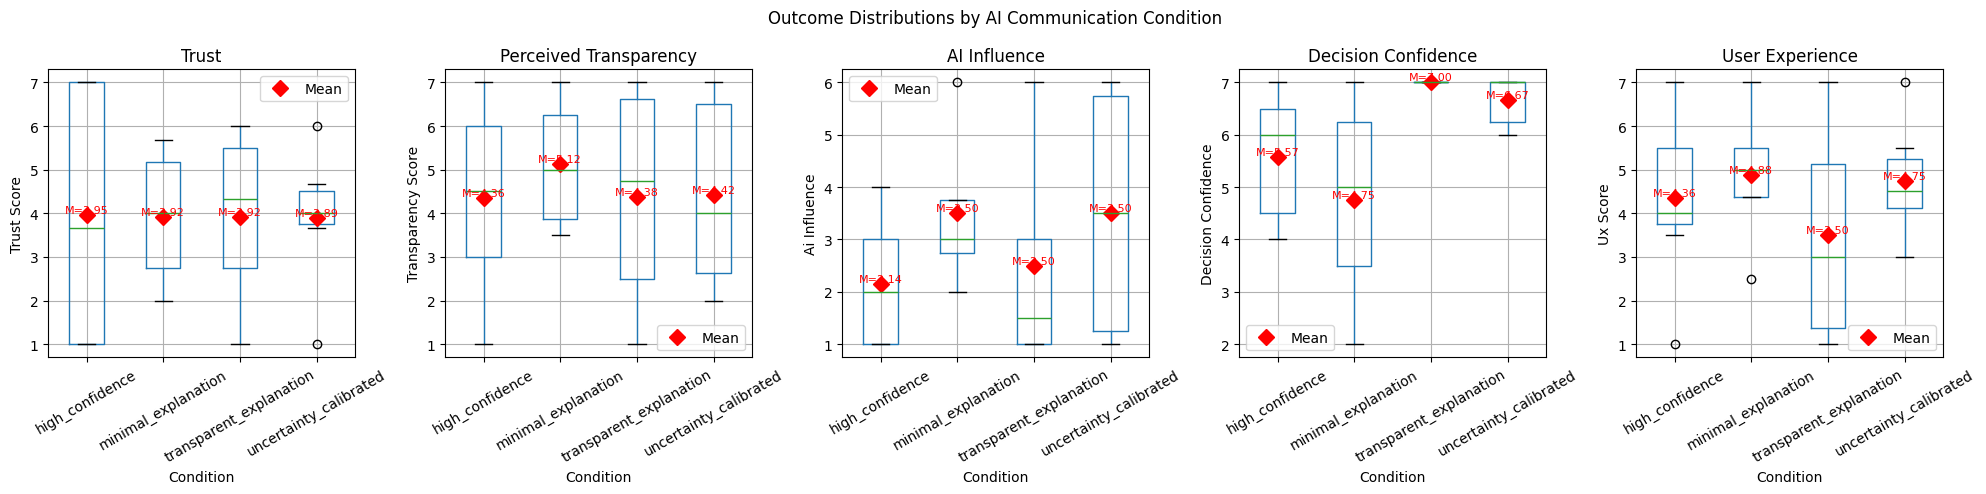

In [28]:
metrics = ["trust_score", "transparency_score", "ai_influence", "decision_confidence", "ux_score"]
metric_titles = {
    "trust_score": "Trust",
    "transparency_score": "Perceived Transparency",
    "ai_influence": "AI Influence",
    "decision_confidence": "Decision Confidence",
    "ux_score": "User Experience"
}

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5), sharey=False)

for i, metric in enumerate(metrics):
    dataset.boxplot(column=metric, by="condition_key", ax=axes[i])
    
    means = dataset.groupby("condition_key")[metric].mean()
    
    axes[i].plot(
        range(1, len(means) + 1),
        means.values,
        color="red",
        marker="D",
        linestyle="",
        markersize=8,
        label="Mean"
    )

    for x, mean_value in enumerate(means.values, start=1):
        axes[i].text(
            x,
            mean_value,
            f"M={mean_value:.2f}",
            color="red",
            ha="center",
            va="bottom",
            fontsize=8
        )

    axes[i].legend()
    axes[i].set_title(metric_titles[metric])
    axes[i].set_xlabel("Condition")
    axes[i].set_ylabel(metric.replace("_", " ").title())
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Outcome Distributions by AI Communication Condition")
plt.tight_layout()
plt.show()

Because outcome measures were based on Likert-style ratings and condition sample sizes were small and uneven, Kruskal-Wallis tests were used to explore whether outcome distributions differed across the four AI communication conditions.

In [29]:
from scipy.stats import kruskal

# metrics = ["trust_score", "transparency_score", "ai_influence", "decision_confidence", "ux_score"]
# metric_titles = {
#     "trust_score": "Trust",
#     "transparency_score": "Perceived Transparency",
#     "ai_influence": "AI Influence",
#     "decision_confidence": "Decision Confidence",
#     "ux_score": "User Experience",
# }

kruskal_results = []

for metric in metrics:
    groups = [
        group[metric].dropna()
        for _, group in dataset.groupby("condition_key")
    ]
    statistic, p_value = kruskal(*groups)

    kruskal_results.append({
        "outcome": metric_titles[metric],
        "h_statistic": statistic,
        "p_value": p_value,
    })

kruskal_results = pd.DataFrame(kruskal_results)
kruskal_results["p_value"] = kruskal_results["p_value"].round(4)
kruskal_results["h_statistic"] = kruskal_results["h_statistic"].round(3)
kruskal_results["significant_at_0.05"] = kruskal_results["p_value"] < 0.05

kruskal_results


,outcome,h_statistic,p_value,significant_at_0.05
0,Trust,0.017,0.9994,False
1,Perceived Transparency,0.464,0.9267,False
2,AI Influence,2.432,0.4877,False
3,Decision Confidence,7.499,0.0576,False
4,User Experience,0.917,0.8213,False


The p-value for decision confidence is close to $.05$, therefore we follow up with Dunn's test.
**Kruskal-Wallis Tests**
Kruskal-Wallis tests were used to examine whether outcome distributions differed across the four AI communication conditions. None of the five outcomes showed a statistically significant difference across conditions at the $p < .05$ level.

Trust showed virtually no difference across conditions, $H = 0.017, p = .9994$, suggesting that participants’ trust ratings were highly similar regardless of communication style. Perceived transparency also did not differ significantly, $H = 0.464, p = .9267$. AI influence was not significantly different across conditions, $H = 2.432, p = .4877$, indicating that participants did not report meaningfully different levels of AI influence based on condition.

Decision confidence showed the strongest pattern, $H = 7.499, p = .0576$, but did not reach conventional statistical significance. This suggests a possible trend where communication style may have affected confidence, but the evidence is not strong enough to conclude a reliable difference in this sample. User experience also did not differ significantly across conditions, $H = 0.917, p = .8213$.

Overall, the Kruskal-Wallis results suggest that the four communication styles did not produce statistically significant differences in trust, transparency, AI influence, decision confidence, or user experience, though decision confidence may be worth discussing descriptively.

In [30]:
from itertools import combinations
from scipy.stats import rankdata, norm
from statsmodels.stats.multitest import multipletests

decision_confidence = dataset[['condition_key', 'decision_confidence']].dropna().copy()
decision_confidence['rank'] = rankdata(decision_confidence['decision_confidence'])

condition_order = ["high_confidence", "minimal_explanation", "transparent_explanation", "uncertainty_calibrated"]
group_stats = (
    decision_confidence
    .groupby('condition_key')
    .agg(
        n=('decision_confidence', 'size'),
        rank_sum=('rank', 'sum'),
        mean=('decision_confidence', 'mean')
    )
    .reindex(condition_order)
)

N = len(decision_confidence)
tie_counts = decision_confidence['decision_confidence'].value_counts()
tie_term = sum(t**3 - t for t in tie_counts if t > 1)
tie_correction = 1 - tie_term / (N**3 - N) if N > 1 else 1

pairwise_results = []

for cond1, cond2 in combinations(condition_order, 2):
    n1 = group_stats.loc[cond1, 'n']
    n2 = group_stats.loc[cond2, 'n']
    R1 = group_stats.loc[cond1, 'rank_sum']
    R2 = group_stats.loc[cond2, 'rank_sum']

    se = ((N * (N + 1) / 12) * tie_correction * (1 / n1 + 1 / n2)) ** 0.5
    z = (R1 / n1 - R2 / n2) / se
    p = 2 * norm.sf(abs(z))

    pairwise_results.append({
        'condition_1': cond1,
        'condition_2': cond2,
        'mean_1': group_stats.loc[cond1, 'mean'],
        'mean_2': group_stats.loc[cond2, 'mean'],
        'z_stat': z,
        'p_value': p,
    })

pairwise_results = pd.DataFrame(pairwise_results)
pairwise_results['p_adj_holm'] = multipletests(pairwise_results['p_value'], method='holm')[1].round(4)
pairwise_results['p_adj_bonferroni'] = multipletests(pairwise_results['p_value'], method='bonferroni')[1].round(4)
pairwise_results[['condition_1', 'condition_2', 'mean_1', 'mean_2', 'z_stat', 'p_value', 'p_adj_holm', 'p_adj_bonferroni']]

,condition_1,condition_2,mean_1,mean_2,z_stat,p_value,p_adj_holm,p_adj_bonferroni
0,high_confidence,minimal_explanation,5.571429,4.750000,0.400417,0.688850,0.9360,1.0000
1,high_confidence,transparent_explanation,5.571429,7.000000,-2.122208,0.033820,0.1691,0.2029
2,high_confidence,uncertainty_calibrated,5.571429,6.666667,-1.548811,0.121427,0.3643,0.7286
3,minimal_explanation,transparent_explanation,4.750000,7.000000,-2.236068,0.025347,0.1521,0.1521
4,minimal_explanation,uncertainty_calibrated,4.750000,6.666667,-1.723715,0.084759,0.3390,0.5086
5,transparent_explanation,uncertainty_calibrated,7.000000,6.666667,0.725775,0.467977,0.9360,1.0000


**Pairwise Comparisons For Decision Confidence**
Because decision confidence was the closest to significance in the Kruskal-Wallis test, pairwise comparisons were examined to explore where differences may have occurred.

The transparent explanation condition had the highest mean decision confidence, $M = 7.00$, followed by uncertainty-calibrated, $M = 6.67$, high confidence, $M = 5.57$, and minimal explanation, $M = 4.75$.

Before correction, two pairwise comparisons were statistically significant: high confidence vs. transparent explanation, $p = .0338$, and minimal explanation vs. transparent explanation, $p = .0253$. However, after correcting for multiple comparisons using Holm or Bonferroni adjustments, none of the pairwise comparisons remained statistically significant.

This means the pairwise results should be interpreted as exploratory. They suggest that transparent explanations may be associated with higher decision confidence, especially compared with high-confidence or minimal-explanation messages, but the evidence is not strong enough to make a firm statistical claim.


In [31]:
from scipy.stats import levene

variance_results = []

for metric in metrics:
    groups = [
        group[metric].dropna()
        for _, group in dataset.groupby("condition_key")
    ]
    statistic, p_value = levene(*groups, center="median")

    variance_results.append({
        "outcome": metric_titles[metric],
        "test": "Brown-Forsythe / Levene median-centered",
        "statistic": statistic,
        "p_value": p_value,
    })

variance_results = pd.DataFrame(variance_results)
variance_results["statistic"] = variance_results["statistic"].round(3)
variance_results["p_value"] = variance_results["p_value"].round(4)
variance_results["significant_at_0.05"] = variance_results["p_value"] < 0.05

variance_results


,outcome,test,statistic,p_value,significant_at_0.05
0,Trust,Brown-Forsythe / Levene median-centered,2.383,0.1052,False
1,Perceived Transparency,Brown-Forsythe / Levene median-centered,0.787,0.5175,False
2,AI Influence,Brown-Forsythe / Levene median-centered,1.289,0.3101,False
3,Decision Confidence,Brown-Forsythe / Levene median-centered,5.416,0.0084,True
4,User Experience,Brown-Forsythe / Levene median-centered,1.079,0.3846,False


**Variance Tests**
Brown-Forsythe tests, a median-centered version of Levene’s test, were used to examine whether the variability of responses differed across conditions.

Most outcomes did not show significant differences in variance across conditions. Trust was not significant, $p = .1052$; perceived transparency was not significant, $p = .5175$; AI influence was not significant, $p = .3101$; and user experience was not significant, $p = .3846$.

Decision confidence was the only outcome with a significant variance difference across conditions, $\text{statistic} = 5.416, p = .0084$. This indicates that the conditions differed not only in average confidence descriptively, but also in how consistent participants’ confidence ratings were within each condition.

Taken together, the results suggest that communication style did not produce statistically significant differences in central tendency for the main outcomes, but decision confidence showed the most notable pattern: it approached significance in the Kruskal-Wallis test, showed exploratory pairwise differences before correction, and had significantly different variance across conditions.

Here’s a report-ready write-up for each set of results.

**Kruskal-Wallis Tests**
Kruskal-Wallis tests were used to examine whether outcome distributions differed across the four AI communication conditions. None of the five outcomes showed a statistically significant difference across conditions at the $p < .05$ level.

Trust showed virtually no difference across conditions, $H = 0.017, p = .9994$, suggesting that participants’ trust ratings were highly similar regardless of communication style. Perceived transparency also did not differ significantly, $H = 0.464, p = .9267$. AI influence was not significantly different across conditions, $H = 2.432, p = .4877$, indicating that participants did not report meaningfully different levels of AI influence based on condition.

Decision confidence showed the strongest pattern, $H = 7.499, p = .0576$, but did not reach conventional statistical significance. This suggests a possible trend where communication style may have affected confidence, but the evidence is not strong enough to conclude a reliable difference in this sample. User experience also did not differ significantly across conditions, $H = 0.917, p = .8213$.

Overall, the Kruskal-Wallis results suggest that the four communication styles did not produce statistically significant differences in trust, transparency, AI influence, decision confidence, or user experience, though decision confidence may be worth discussing descriptively.

**Pairwise Comparisons For Decision Confidence**
Because decision confidence was the closest to significance in the Kruskal-Wallis test, pairwise comparisons were examined to explore where differences may have occurred.

The transparent explanation condition had the highest mean decision confidence, $M = 7.00$, followed by uncertainty-calibrated, $M = 6.67$, high confidence, $M = 5.57$, and minimal explanation, $M = 4.75$.

Before correction, two pairwise comparisons were statistically significant: high confidence vs. transparent explanation, $p = .0338$, and minimal explanation vs. transparent explanation, $p = .0253$. However, after correcting for multiple comparisons using Holm or Bonferroni adjustments, none of the pairwise comparisons remained statistically significant.

This means the pairwise results should be interpreted as exploratory. They suggest that transparent explanations may be associated with higher decision confidence, especially compared with high-confidence or minimal-explanation messages, but the evidence is not strong enough to make a firm statistical claim.

**Variance Tests**
Brown-Forsythe tests, a median-centered version of Levene’s test, were used to examine whether the variability of responses differed across conditions.

Most outcomes did not show significant differences in variance across conditions. Trust was not significant, $p = .1052$; perceived transparency was not significant, $p = .5175$; AI influence was not significant, $p = .3101$; and user experience was not significant, $p = .3846$.

Decision confidence was the only outcome with a significant variance difference across conditions, $\text{statistic} = 5.416, p = .0084$. This indicates that the conditions differed not only in average confidence descriptively, but also in how consistent participants’ confidence ratings were within each condition.

Taken together, the results suggest that communication style did not produce statistically significant differences in central tendency for the main outcomes, but decision confidence showed the most notable pattern: it approached significance in the Kruskal-Wallis test, showed exploratory pairwise differences before correction, and had significantly different variance across conditions.

##### Correlation Analysis Among Trust, Transparency, Influence, and Confidence

In [32]:
corr_vars = [
    "trust_score",
    "transparency_score",
    "ai_influence",
    "decision_confidence",
    "baseline_trust",
    "comfort"
]

corr = dataset[corr_vars].corr()
corr

,trust_score,transparency_score,ai_influence,decision_confidence,baseline_trust,comfort
trust_score,1.000000,0.695850,-0.256918,0.374472,-0.118514,-0.163065
transparency_score,0.695850,1.000000,0.130322,0.185155,-0.003395,-0.311108
ai_influence,-0.256918,0.130322,1.000000,-0.054929,0.263454,0.067310
decision_confidence,0.374472,0.185155,-0.054929,1.000000,0.282395,0.250182
baseline_trust,-0.118514,-0.003395,0.263454,0.282395,1.000000,0.581543
comfort,-0.163065,-0.311108,0.067310,0.250182,0.581543,1.000000


### Correlation Summary

A correlation matrix was used to examine relationships among trust, perceived transparency, AI influence, decision confidence, baseline trust, and comfort using Pearson correlation coefficients.

The strongest relationship was between **trust score** and **transparency score**, $r = 0.696$. This suggests that participants who perceived the AI as more transparent also tended to report higher trust in the AI recommendation.

Baseline trust and comfort were also moderately positively related, $r = 0.582$, indicating that participants who generally trusted AI recommendations also tended to feel more comfortable using AI to support decisions.

Decision confidence showed a small-to-moderate positive relationship with trust, $r = 0.374$, and baseline trust, $r = 0.282$. This suggests that participants with higher trust may have felt somewhat more confident in their decisions, although these relationships should be interpreted cautiously given the small sample size.

AI influence was weakly negatively related to trust, $r = -0.257$, and nearly unrelated to decision confidence, $r = -0.055$. This suggests that higher trust did not necessarily translate into greater self-reported AI influence in this sample.

Overall, the correlation results suggest that perceived transparency was most closely associated with trust, while AI influence appeared relatively independent from the other measured variables. Because the sample size was small, these correlations should be interpreted as exploratory rather than conclusive.

##### Pearson Correlations and P-Values Among Study Measures

In [33]:
import scipy.stats as stats

corr_with_p = pd.DataFrame(index=corr_vars, columns=corr_vars)

for col1 in corr_vars:
    for col2 in corr_vars:
        r, p = stats.pearsonr(dataset[col1], dataset[col2])
        corr_with_p.loc[col1, col2] = f"{r:.3f} (p={p:.4f})"

corr_with_p


,trust_score,transparency_score,ai_influence,decision_confidence,baseline_trust,comfort
trust_score,1.000 (p=0.0000),0.696 (p=0.0005),-0.257 (p=0.2609),0.374 (p=0.0944),-0.119 (p=0.6089),-0.163 (p=0.4800)
transparency_score,0.696 (p=0.0005),1.000 (p=0.0000),0.130 (p=0.5734),0.185 (p=0.4217),-0.003 (p=0.9883),-0.311 (p=0.1698)
ai_influence,-0.257 (p=0.2609),0.130 (p=0.5734),1.000 (p=0.0000),-0.055 (p=0.8131),0.263 (p=0.2485),0.067 (p=0.7719)
decision_confidence,0.374 (p=0.0944),0.185 (p=0.4217),-0.055 (p=0.8131),1.000 (p=0.0000),0.282 (p=0.2149),0.250 (p=0.2740)
baseline_trust,-0.119 (p=0.6089),-0.003 (p=0.9883),0.263 (p=0.2485),0.282 (p=0.2149),1.000 (p=0.0000),0.582 (p=0.0057)
comfort,-0.163 (p=0.4800),-0.311 (p=0.1698),0.067 (p=0.7719),0.250 (p=0.2740),0.582 (p=0.0057),1.000 (p=0.0000)


### Interpretation of Pearson Correlations

This table reports Pearson correlation coefficients with p-values for the main study measures. Correlation coefficients range from $-1$ to $1$, where positive values indicate that two variables tend to increase together, negative values indicate that one variable tends to decrease as the other increases, and values close to $0$ indicate little or no linear relationship.

The strongest relationship was between **trust score** and **transparency score**, $r = 0.696, p = .0005$. This indicates a strong positive and statistically significant relationship: participants who perceived the AI as more transparent also tended to report higher trust in the AI recommendation.

A second significant relationship was observed between **baseline trust** and **comfort**, $r = 0.582, p = .0057$. Participants who generally trusted AI recommendations also tended to feel more comfortable using AI to support decisions.

Decision confidence showed a moderate positive relationship with trust, $r = 0.374, p = .0944$, but this relationship was not statistically significant at the $p < .05$ level. This suggests a possible trend, but the current sample does not provide enough evidence to conclude that higher trust was reliably associated with higher decision confidence.

AI influence was not significantly related to trust, transparency, decision confidence, baseline trust, or comfort. This suggests that participants' self-reported influence from the AI recommendation may have operated somewhat independently from their trust and comfort ratings.

The correlation results suggest that **perceived transparency was strongly associated with trust**, and **baseline trust was associated with comfort using AI**. Other relationships were weaker and should be interpreted cautiously given the small sample size.

**Question: Is transparency associated with trust?**  
Yes. Transparency was strongly and positively associated with trust, $r = 0.696, p = .0005$. This indicates that participants who perceived the AI recommendation as more transparent also tended to report higher levels of trust in the AI.

This was one of the strongest relationships observed in the correlation analysis. Because the p-value is below the conventional significance threshold of $p < .05$, the association is statistically significant, meaning it is unlikely to be due to random variation in this sample.

Substantively, this suggests that participants may have trusted the AI more when they felt they understood the reasoning behind its recommendation. In the context of this study, transparency appears to be an important factor related to perceived trustworthiness. However, because this is a correlation, it does not prove that transparency caused trust to increase; it only shows that the two were closely related in the participant responses.

 **Question: Is trust associated with AI influence?**  
No statistically significant association was found between trust and AI influence. Trust was weakly negatively correlated with AI influence, $r = -0.257, p = .2609$.

This suggests that participants who reported higher trust in the AI did not necessarily report being more influenced by its recommendation. In fact, the negative direction means higher trust was slightly associated with lower reported AI influence, but the relationship was weak and not statistically significant.

Because the p-value is greater than $p < .05$, this result should be interpreted as no reliable evidence of an association in this sample. In practical terms, trust and influence may not be the same thing: participants could trust the AI’s reasoning while still relying primarily on their own judgment.

**Question: Is baseline trust associated with AI influence?**  
No statistically significant association was found between baseline trust and AI influence. Baseline trust was weakly positively correlated with AI influence, $r = 0.263, p = .2485$.

This suggests that participants who generally trusted AI recommendations before the task reported slightly higher AI influence, but the relationship was weak and not statistically significant.

Because the p-value is greater than $p < .05$, there is not enough evidence to conclude that participants’ general trust in AI was reliably associated with how much the AI influenced their decision in this study. This may indicate that baseline attitudes toward AI did not strongly predict reliance in this specific task context.

**Question: Is decision condidence associated with trust?**  
Decision confidence was moderately and positively associated with trust, $r = 0.374, p = .0944$, but this relationship was not statistically significant at the $p < .05$ level.

This suggests that participants who reported higher trust in the AI tended to also report somewhat higher confidence in their decision. However, because the p-value was above the conventional significance threshold, there is not enough evidence to conclude that this association is reliable in the current sample.

Substantively, this may indicate a possible trend: trusting the AI could be related to feeling more confident after making a decision, but the study’s small sample size limits the strength of this conclusion.

##### Regression

This is the final quantitative analysis of your study. The goal is not to prove causation (your sample is too small), but to determine which variables are most associated with AI influence while controlling for the others.

Think of regression as asking: "After accounting for trust and baseline trust, does transparency still explain differences in AI influence?" Unlike the earlier correlation analysis (one relationship at a time), regression looks at several predictors simultaneously.

Regression Workflow
Objective:
Determine which factors are associated with participants' reported AI influence.

Dependent (Outcome) Variable
AI Influence (ai_influence)
Predictor Variables
Trust (trust_score)
Transparency (transparency_score)
Baseline Trust (baseline_trust)

In [34]:
import statsmodels.formula.api as smf

model = smf.ols(
    "ai_influence ~ trust_score + transparency_score + baseline_trust",
    data=dataset
).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           ai_influence   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.161
Method:                 Least Squares   F-statistic:                     2.277
Date:                Sun, 28 Jun 2026   Prob (F-statistic):              0.116
Time:                        22:52:44   Log-Likelihood:                -39.557
No. Observations:                  21   AIC:                             87.11
Df Residuals:                      17   BIC:                             91.29
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.6346      1.544      1.059      0.305      -1.623       4.892
trust_score           -0.5695      0.261     -2.183      0.043      -1.120      -0.019
transparency_score     0.5240      0.264      1.986      0.063      -0.033       1.081
baseline_trust         0.2450      0.267      0.918      0.371      -0.318       0.808
==============================================================================
Omnibus:                        2.095   Durbin-Watson:                   2.651
Prob(Omnibus):                  0.351   Jarque-Bera (JB):                1.773
Skew:                           0.634   Prob(JB):                        0.412
Kurtosis:                       2.354   Cond. No.                         31.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

This regression tests whether **trust score**, **transparency score**, and **baseline trust** predict participants’ reported **AI influence**.

The model is:

$$
AI\ Influence = b_0 + b_1(Trust) + b_2(Transparency) + b_3(Baseline\ Trust)
$$

**Overall Model**
The dependent variable is `ai_influence`, meaning the model is trying to explain how much participants said the AI influenced their decision.

The model used 21 observations. The $R^2 = 0.287$, which means the predictors explain about **28.7% of the variation in AI influence**. The adjusted $R^2 = 0.161$, which is lower because it accounts for the number of predictors and the small sample size.

The overall model was not statistically significant:

$$
F = 2.277,\ p = .116
$$

This means that, taken together, trust, transparency, and baseline trust did not significantly predict AI influence at the conventional $p < .05$ level.

**Predictors**
**Trust score** had a negative and statistically significant coefficient:

$$
b = -0.5695,\ p = .043
$$

This means that, controlling for transparency and baseline trust, higher trust scores were associated with **lower reported AI influence**. For every 1-point increase in trust score, AI influence decreased by about 0.57 points on average.

This is somewhat counterintuitive. It suggests that participants who trusted the AI more did not necessarily feel more influenced by it. One possible interpretation is that participants may have trusted the recommendation because it aligned with their own judgment, not because it changed their decision.

**Transparency score** had a positive but not statistically significant coefficient:

$$
b = 0.5240,\ p = .063
$$

This suggests a possible trend: higher perceived transparency may be associated with higher AI influence after controlling for trust and baseline trust. However, because $p = .063$ is above $p < .05$, this result should be treated as suggestive rather than conclusive.

**Baseline trust** was not a significant predictor:

$$
b = 0.2450,\ p = .371
$$

This means participants’ general trust in AI before the task did not significantly predict how much they reported being influenced by the AI recommendation.

**Main Interpretation**
The model suggests that the relationship between trust and AI influence is more complicated than expected. Trust alone does not necessarily mean reliance. In this sample, higher trust was associated with lower self-reported AI influence when transparency and baseline trust were held constant.


An OLS regression was conducted to examine whether trust, perceived transparency, and baseline trust predicted self-reported AI influence. The overall model explained 28.7% of the variance in AI influence, $R^2 = .287$, but was not statistically significant, $F(3, 17) = 2.277, p = .116$.

Trust score was a significant negative predictor of AI influence, $b = -0.570, p = .043$, indicating that higher trust was associated with lower reported AI influence after controlling for transparency and baseline trust. Transparency showed a positive but non-significant trend, $b = 0.524, p = .063$, while baseline trust was not significant, $b = 0.245, p = .371$.

These findings suggest that participants who trusted the AI more did not necessarily report being more influenced by it. Trust may have reflected agreement with the AI’s reasoning rather than reliance on the AI to make the decision.

## Main Takeaways

The regression model explored whether **trust**, **perceived transparency**, and **baseline trust** predicted **AI influence**.

The overall model was **not statistically significant**, $F(3, 17) = 2.277, p = .116$. This means the three predictors, taken together, did not reliably explain AI influence in this sample.

The model explained about **28.7% of the variance** in AI influence, $R^2 = .287$, but the adjusted value was lower, $R^2_{adj} = .161$, suggesting the model’s explanatory power is modest and may be limited by the small sample size.

**Trust was a significant negative predictor** of AI influence, $b = -0.570, p = .043$. Participants with higher trust scores actually reported lower AI influence after controlling for transparency and baseline trust.

**Transparency showed a positive trend**, $b = 0.524, p = .063$, but it was not statistically significant. This suggests transparency may be related to greater AI influence, but the evidence is not strong enough to make a firm claim.

**Baseline trust was not significant**, $b = 0.245, p = .371$. Participants’ general trust in AI did not reliably predict how much the AI influenced their decision.

The key interpretation is that **trust and influence are not the same thing**. Participants may have trusted the AI because it aligned with their own reasoning, not because it changed or strongly shaped their decision.

#### Qualitative Analysis by Condition

In [35]:
# Create a qualitative subset
qual = dataset[
    [
        "condition_key",
        "open_trust",
        "open_explanation",
        "open_improvement"
    ]
].copy()

# Sort by condition
qual = qual.sort_values("condition_key")

# Export qualitative responses
qual.to_csv("qualitative_responses_by_condition.csv", index=False)

qual

,condition_key,open_trust,open_explanation,open_improvement
3,high_confidence,no_response,no_response,no_response
4,high_confidence,The ai singled out the most urgent task accura...,"The explanation was clear, coherent and accurate.",adding condiitons to recommendations would mak...
7,high_confidence,no_response,no_response,no_response
15,high_confidence,My understanding of AI is that it pulls materi...,"Yes, the table was helpful in displaying what ...",It would’ve been nice to have a sentence or tw...
17,high_confidence,It was not trustworthy but its decision concur...,There was no explanation.,An explanation.
18,high_confidence,The answer was concise and agreed with the int...,"It felt appropriate for the scenario given, al...",no_response
20,high_confidence,"""Clearly"" is a red flag",Insufficient,More details in the context
0,minimal_explanation,no_response,no_response,no_response
11,minimal_explanation,Quick and straight to the point. Always seems ...,Helpful,I assume AI will only get smarter or more elab...
13,minimal_explanation,Followed logic that was not foreign to me,Helpful,"Not sure exactly, I use as a guide and informa..."


## Qualitative Coding of Open-Ended Responses

In [36]:
# Remove rows where all open-ended responses are no_response
qual_responses = qual[
    ~(
        (qual["open_trust"] == "no_response") &
        (qual["open_explanation"] == "no_response") &
        (qual["open_improvement"] == "no_response")
    )
].copy()

qual_responses

,condition_key,open_trust,open_explanation,open_improvement
4,high_confidence,The ai singled out the most urgent task accura...,"The explanation was clear, coherent and accurate.",adding condiitons to recommendations would mak...
15,high_confidence,My understanding of AI is that it pulls materi...,"Yes, the table was helpful in displaying what ...",It would’ve been nice to have a sentence or tw...
17,high_confidence,It was not trustworthy but its decision concur...,There was no explanation.,An explanation.
18,high_confidence,The answer was concise and agreed with the int...,"It felt appropriate for the scenario given, al...",no_response
20,high_confidence,"""Clearly"" is a red flag",Insufficient,More details in the context
11,minimal_explanation,Quick and straight to the point. Always seems ...,Helpful,I assume AI will only get smarter or more elab...
13,minimal_explanation,Followed logic that was not foreign to me,Helpful,"Not sure exactly, I use as a guide and informa..."
14,minimal_explanation,It was not trustworthy because it suggested an...,The explanation was helpful.,no_response
1,transparent_explanation,The advice AI gave just made sense and there w...,"Helpful,",If you really want to know how much AI has an ...
6,transparent_explanation,"My baseline trust in the AI is very low, and I...","The explanation felt excessive, going beyond t...",More data points.


In [37]:
qual_responses["trust_theme"] = ""
qual_responses["explanation_theme"] = ""
qual_responses["improvement_theme"] = ""

qual_responses

,condition_key,open_trust,open_explanation,open_improvement,trust_theme,explanation_theme,improvement_theme
4,high_confidence,The ai singled out the most urgent task accura...,"The explanation was clear, coherent and accurate.",adding condiitons to recommendations would mak...,,,
15,high_confidence,My understanding of AI is that it pulls materi...,"Yes, the table was helpful in displaying what ...",It would’ve been nice to have a sentence or tw...,,,
17,high_confidence,It was not trustworthy but its decision concur...,There was no explanation.,An explanation.,,,
18,high_confidence,The answer was concise and agreed with the int...,"It felt appropriate for the scenario given, al...",no_response,,,
20,high_confidence,"""Clearly"" is a red flag",Insufficient,More details in the context,,,
11,minimal_explanation,Quick and straight to the point. Always seems ...,Helpful,I assume AI will only get smarter or more elab...,,,
13,minimal_explanation,Followed logic that was not foreign to me,Helpful,"Not sure exactly, I use as a guide and informa...",,,
14,minimal_explanation,It was not trustworthy because it suggested an...,The explanation was helpful.,no_response,,,
1,transparent_explanation,The advice AI gave just made sense and there w...,"Helpful,",If you really want to know how much AI has an ...,,,
6,transparent_explanation,"My baseline trust in the AI is very low, and I...","The explanation felt excessive, going beyond t...",More data points.,,,


In [38]:
# First-pass manual qualitative coding

qual_responses["trust_theme"] = ""
qual_responses["explanation_theme"] = ""
qual_responses["improvement_theme"] = ""

# High confidence condition
qual_responses.loc[4, "trust_theme"] = "accurate_prioritization"
qual_responses.loc[4, "explanation_theme"] = "clear_and_helpful"
qual_responses.loc[4, "improvement_theme"] = "add_conditions_or_context"

qual_responses.loc[15, "trust_theme"] = "general_ai_trust"
qual_responses.loc[15, "explanation_theme"] = "task_table_helpful"
qual_responses.loc[15, "improvement_theme"] = "add_introductory_context"

qual_responses.loc[17, "trust_theme"] = "agreement_but_low_trust"
qual_responses.loc[17, "explanation_theme"] = "no_explanation"
qual_responses.loc[17, "improvement_theme"] = "add_explanation"

qual_responses.loc[18, "trust_theme"] = "aligned_with_intuition"
qual_responses.loc[18, "explanation_theme"] = "appropriate_but_brief"
qual_responses.loc[18, "improvement_theme"] = "no_response"

qual_responses.loc[20, "trust_theme"] = "overconfidence_concern"
qual_responses.loc[20, "explanation_theme"] = "insufficient"
qual_responses.loc[20, "improvement_theme"] = "more_context"

# Minimal explanation condition
qual_responses.loc[11, "trust_theme"] = "concise_and_logical"
qual_responses.loc[11, "explanation_theme"] = "helpful"
qual_responses.loc[11, "improvement_theme"] = "general_future_improvement"

qual_responses.loc[13, "trust_theme"] = "logical_and_familiar"
qual_responses.loc[13, "explanation_theme"] = "helpful"
qual_responses.loc[13, "improvement_theme"] = "human_decision_authority"

qual_responses.loc[14, "trust_theme"] = "unusual_recommendation"
qual_responses.loc[14, "explanation_theme"] = "helpful"
qual_responses.loc[14, "improvement_theme"] = "no_response"

# Transparent explanation condition
qual_responses.loc[1, "trust_theme"] = "made_sense"
qual_responses.loc[1, "explanation_theme"] = "helpful"
qual_responses.loc[1, "improvement_theme"] = "measure_decision_change"

qual_responses.loc[6, "trust_theme"] = "low_baseline_trust"
qual_responses.loc[6, "explanation_theme"] = "excessive_or_overextended"
qual_responses.loc[6, "improvement_theme"] = "more_data"

qual_responses.loc[9, "trust_theme"] = "general_ai_skepticism"
qual_responses.loc[9, "explanation_theme"] = "irrelevant"
qual_responses.loc[9, "improvement_theme"] = "no_improvement"

qual_responses.loc[19, "trust_theme"] = "reasoning_explained"
qual_responses.loc[19, "explanation_theme"] = "helpful"
qual_responses.loc[19, "improvement_theme"] = "no_response"

# Uncertainty-calibrated condition
qual_responses.loc[2, "trust_theme"] = "sound_reasoning"
qual_responses.loc[2, "explanation_theme"] = "helpful"
qual_responses.loc[2, "improvement_theme"] = "more_examples"

qual_responses.loc[10, "trust_theme"] = "uncertainty_language_concern"
qual_responses.loc[10, "explanation_theme"] = "redundant"
qual_responses.loc[10, "improvement_theme"] = "avoid_excessive_uncertainty_language"

qual_responses.loc[16, "trust_theme"] = "logical_but_uncertainty_concern"
qual_responses.loc[16, "explanation_theme"] = "insufficient"
qual_responses.loc[16, "improvement_theme"] = "conditional_reasoning"

qual_responses

,condition_key,open_trust,open_explanation,open_improvement,trust_theme,explanation_theme,improvement_theme
4,high_confidence,The ai singled out the most urgent task accura...,"The explanation was clear, coherent and accurate.",adding condiitons to recommendations would mak...,accurate_prioritization,clear_and_helpful,add_conditions_or_context
15,high_confidence,My understanding of AI is that it pulls materi...,"Yes, the table was helpful in displaying what ...",It would’ve been nice to have a sentence or tw...,general_ai_trust,task_table_helpful,add_introductory_context
17,high_confidence,It was not trustworthy but its decision concur...,There was no explanation.,An explanation.,agreement_but_low_trust,no_explanation,add_explanation
18,high_confidence,The answer was concise and agreed with the int...,"It felt appropriate for the scenario given, al...",no_response,aligned_with_intuition,appropriate_but_brief,no_response
20,high_confidence,"""Clearly"" is a red flag",Insufficient,More details in the context,overconfidence_concern,insufficient,more_context
11,minimal_explanation,Quick and straight to the point. Always seems ...,Helpful,I assume AI will only get smarter or more elab...,concise_and_logical,helpful,general_future_improvement
13,minimal_explanation,Followed logic that was not foreign to me,Helpful,"Not sure exactly, I use as a guide and informa...",logical_and_familiar,helpful,human_decision_authority
14,minimal_explanation,It was not trustworthy because it suggested an...,The explanation was helpful.,no_response,unusual_recommendation,helpful,no_response
1,transparent_explanation,The advice AI gave just made sense and there w...,"Helpful,",If you really want to know how much AI has an ...,made_sense,helpful,measure_decision_change
6,transparent_explanation,"My baseline trust in the AI is very low, and I...","The explanation felt excessive, going beyond t...",More data points.,low_baseline_trust,excessive_or_overextended,more_data


In [39]:
trust_theme_counts = qual_responses["trust_theme"].value_counts()
explanation_theme_counts = qual_responses["explanation_theme"].value_counts()
improvement_theme_counts = qual_responses["improvement_theme"].value_counts()

trust_theme_counts, explanation_theme_counts, improvement_theme_counts

(trust_theme
 accurate_prioritization            1
 general_ai_trust                   1
 agreement_but_low_trust            1
 aligned_with_intuition             1
 overconfidence_concern             1
 concise_and_logical                1
 logical_and_familiar               1
 unusual_recommendation             1
 made_sense                         1
 low_baseline_trust                 1
 general_ai_skepticism              1
 reasoning_explained                1
 sound_reasoning                    1
 uncertainty_language_concern       1
 logical_but_uncertainty_concern    1
 Name: count, dtype: int64,
 explanation_theme
 helpful                      6
 insufficient                 2
 clear_and_helpful            1
 task_table_helpful           1
 no_explanation               1
 appropriate_but_brief        1
 excessive_or_overextended    1
 irrelevant                   1
 redundant                    1
 Name: count, dtype: int64,
 improvement_theme
 no_response                       

In [40]:
pd.crosstab(qual_responses["condition_key"], qual_responses["trust_theme"])

trust_theme,accurate_prioritization,agreement_but_low_trust,aligned_with_intuition,concise_and_logical,general_ai_skepticism,general_ai_trust,logical_and_familiar,logical_but_uncertainty_concern,low_baseline_trust,made_sense,overconfidence_concern,reasoning_explained,sound_reasoning,uncertainty_language_concern,unusual_recommendation
condition_key,,,,,,,,,,,,,,,
high_confidence,1,1,1,0,0,1,0,0,0,0,1,0,0,0,0
minimal_explanation,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1
transparent_explanation,0,0,0,0,1,0,0,0,1,1,0,1,0,0,0
uncertainty_calibrated,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0


The open-ended responses were manually coded using first-cycle thematic coding. Each response was assigned a short descriptive code based on the participant’s main idea. Codes were grouped around trust, explanation quality, and suggested improvements. Because the sample was small, these codes are exploratory and intended to support interpretation of the quantitative findings rather than serve as a standalone qualitative analysis.


## Qualitative Findings by Condition

Open-ended responses were reviewed by condition to identify how participants interpreted the AI recommendation, explanation quality, and possible improvements. Because the number of responses per condition was small, these findings should be interpreted as exploratory.

### High Confidence

Participants in the High Confidence condition gave mixed responses. Some participants found the recommendation trustworthy because it identified the most urgent task or aligned with their own intuitive judgment. For these participants, the AI appeared useful when its recommendation matched the visible task priorities.

However, other participants reacted negatively to the strong confidence language. One participant described the word “clearly” as a red flag, suggesting that confident wording can reduce trust when it feels unsupported. Several comments also indicated that the recommendation would have benefited from more explanation or context.

Overall, the High Confidence condition suggests that strong confidence may be persuasive when the recommendation feels obvious, but it can also create skepticism if the AI does not explain why it is so certain.

### Minimal Explanation

Participants in the Minimal Explanation condition often described the recommendation as quick, logical, and easy to understand. Some participants appeared to value the simplicity of the recommendation, describing it as straight to the point or consistent with their own reasoning.

At the same time, one participant found the recommendation untrustworthy because it seemed unusual or insufficiently justified. This suggests that minimal explanation may work when the recommendation already feels intuitive, but it may be less effective when participants want more reasoning behind the recommendation.

Overall, the Minimal Explanation condition suggests that concise recommendations can feel clear and efficient, but they may not provide enough support for participants who question the recommendation.

### Transparent Explanation

Participants in the Transparent Explanation condition also showed mixed reactions. Some participants found the explanation helpful because it made the AI’s reasoning clear and easy to follow. These responses suggest that transparency can support trust when participants feel the reasoning is relevant and grounded in the task.

However, other participants were more skeptical. One participant said they had low baseline trust in AI and would need more data before increasing trust. Another felt the explanation was excessive and went beyond the available information. This suggests that transparency is not automatically beneficial; explanations need to feel appropriately supported and not overextended.

Overall, the Transparent Explanation condition suggests that explanations can strengthen trust when they clarify reasoning, but too much or poorly bounded explanation may feel excessive or speculative.

### Uncertainty-Calibrated

Participants in the Uncertainty-Calibrated condition often recognized that the AI’s answer was logical or based on sound reasoning. However, the uncertainty language itself produced some skepticism. Participants specifically noted that words such as “moderately” or mild confidence made the AI feel less trustworthy.

Some participants wanted more examples, more conditional reasoning, or more explanation of trade-offs between tasks. This suggests that uncertainty can be useful, but only when paired with enough reasoning to help participants understand why the AI is uncertain.

Overall, the Uncertainty-Calibrated condition suggests that acknowledging uncertainty may make the AI seem more cautious, but it can also reduce perceived trust if users interpret uncertainty as weakness or lack of confidence.

### Cross-Condition Summary

Across conditions, participants tended to trust the AI most when the recommendation aligned with their own reasoning and was supported by clear logic. Trust appeared to depend less on the amount of explanation alone and more on whether the explanation felt appropriate, grounded, and useful.

Both strong confidence and uncertainty language could backfire. Strong confidence sometimes seemed overconfident, while uncertainty language sometimes made the AI seem less reliable. This suggests that communication style should be calibrated carefully: participants preferred recommendations that were concise, logical, and transparent without sounding either overly certain or unnecessarily hesitant.

Several participants also requested more context, examples, conditional reasoning, or a design that asks for the user’s initial decision before showing the AI recommendation. These comments suggest that future versions of the study could better measure AI influence by capturing participants’ decisions before and after exposure to the AI recommendation.
```

## Synthesis of Quantitative and Qualitative Findings

| Quantitative Finding | Qualitative Finding | Design Implication |
|---|---|---|
| Trust scores were very similar across all four conditions, with no significant condition-level differences in the Kruskal-Wallis test, $H = 0.017, p = .9994$. | Participant comments suggest that trust depended less on condition assignment and more on whether the AI recommendation felt logical, intuitive, or aligned with their own reasoning. | AI systems should prioritize recommendations that clearly connect to visible task evidence, rather than relying only on communication style changes to increase trust. |
| Transparency was strongly and positively associated with trust, $r = 0.696, p = .0005$. | Participants often described the AI as trustworthy when it explained its reasoning, singled out the urgent task, or gave a recommendation that “made sense.” | Explanations should make the reasoning process visible and connect directly to the user’s decision context. |
| AI influence was not significantly associated with trust, $r = -0.257, p = .2609$. | Several comments suggest that participants could trust the AI while still treating the final decision as their own. Some trusted the AI because it agreed with their existing judgment, not because it changed their mind. | Designers should distinguish between trust and reliance. A trusted AI recommendation may support confidence without necessarily increasing behavioral dependence. |
| Baseline trust was not significantly associated with AI influence, $r = 0.263, p = .2485$. | Some participants expressed general skepticism toward AI regardless of the recommendation, while others described generally trusting AI based on prior experience. | Systems may need to adapt explanations to users’ prior attitudes toward AI, especially for users with low baseline trust. |
| Decision confidence showed the strongest condition-level trend in the Kruskal-Wallis test, $H = 7.499, p = .0576$, though it was not statistically significant. | Transparent explanation and uncertainty-calibrated responses often helped participants understand the recommendation, but confidence language sometimes created doubt. | Explanations should support user confidence without overstating certainty or introducing unnecessary hesitation. |
| Pairwise comparisons suggested higher decision confidence in the transparent explanation condition before correction, but no pairwise differences remained significant after adjustment. | Some participants in the transparent explanation condition found the reasoning helpful, while others felt it was excessive or went beyond the available data. | Transparency should be concise and bounded. More explanation is not always better if it feels speculative or overextended. |
| Decision confidence showed significantly different variance across conditions in the Brown-Forsythe test, $p = .0084$. | Participant comments showed varied reactions to confidence language: some valued clear recommendations, while others viewed words like “clearly” or “moderately” as red flags. | Confidence language should be calibrated carefully. Users may react differently to certainty and uncertainty depending on whether the explanation feels justified. |
| The regression model predicting AI influence was not significant overall, $F(3, 17) = 2.277, p = .116$, though trust was a significant negative predictor, $b = -0.570, p = .043$. | Participants often described trusting the AI when it agreed with their own reasoning, suggesting trust may reflect agreement rather than influence. | Interfaces should measure influence directly, such as by asking for the user’s initial decision before showing the AI recommendation and then measuring whether the recommendation changes the decision. |
| Minimal explanation had relatively high perceived transparency descriptively, despite providing the least explanation. | Some participants described minimal recommendations as quick, logical, and straight to the point. | In simple decision contexts, concise explanations may feel clearer than detailed ones. Designers should match explanation depth to task complexity. |
| High-confidence messaging did not produce higher trust or influence. | Some participants found the high-confidence wording useful when it matched the obvious task priority, while others viewed strong wording such as “clearly” as a red flag. | Confidence claims should be supported with evidence. Strong certainty without sufficient reasoning may reduce credibility. |
| Uncertainty-calibrated messaging did not clearly increase trust or transparency. | Some participants felt that words such as “moderately” or mild confidence made the AI seem less trustworthy, even when the reasoning was logical. | If uncertainty is communicated, it should be paired with a clear explanation of why uncertainty exists and what evidence supports the recommendation. |

## Final Report

The full final report is available in `final_report.md`.

This report integrates the quantitative findings, qualitative open-response themes, mixed-methods synthesis, and responsible AI design recommendations.